# Time-RCD: эксперименты с маскированием


In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    mean_squared_error, mean_absolute_error
)
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import os, copy

from timercd_model import build_timercd, TimeRCD

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [1]:
!wget https://www.thedatum.org/datasets/TSB-AD-M.zip
!unzip TSB-AD-M.zip

## 1. Загрузка данных

In [ ]:
import glob, re, os
import pandas as pd
import numpy as np

def load_msl_tsb(data_dir: str, entity_ids=None, window_size=256):
    files = sorted(glob.glob(os.path.join(data_dir, "*_MSL_*.csv")))
    if entity_ids is not None:
        files = [f for f in files if any(f"_id_{i}_" in f for i in entity_ids)]

    print(f"Файлов к загрузке: {len(files)}")
    train_parts, test_parts, label_parts = [], [], []

    for fpath in files:
        fname  = os.path.basename(fpath)
        df     = pd.read_csv(fpath)
        tr_len = int(re.search(r"_tr_(\d+)_", fname).group(1))

        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(int)

        if np.abs(X).max() > 10:
            print(f"  SKIP {fname}: выброс max={np.abs(X).max():.1f}")
            continue

        X_train = X[:tr_len][y[:tr_len] == 0]
        if len(X_train) < window_size:
            print(f"  SKIP {fname}: train={len(X_train)} < window={window_size}")
            continue

        train_parts.append(X_train)
        test_parts.append(X[tr_len:])
        label_parts.append(y[tr_len:])
        print(f"  OK {fname}: train={X_train.shape}, "
              f"test={X[tr_len:].shape}, аном={y[tr_len:].mean()*100:.1f}%")

    train_norm = np.concatenate(train_parts, axis=0)  
    test_norm  = np.concatenate(test_parts,  axis=0)  
    labels     = np.concatenate(label_parts, axis=0)

    std_ch = train_norm.std(axis=0)
    good   = std_ch > 1e-3
    train_norm, test_norm = train_norm[:, good], test_norm[:, good]
    print(f"\nКаналов после фильтрации: {good.sum()} (убрали {(~good).sum()})")
    print(f"train={train_norm.shape}, test={test_norm.shape}")
    print(f"Аномалий: {labels.sum()} ({labels.mean()*100:.1f}%)")
    return train_norm, test_norm, labels


WINDOW_SIZE = 256
STRIDE      = 16

train_norm, test_norm, point_labels = load_msl_tsb(
    data_dir    = "TSB-AD-M",
    entity_ids  = None,
    window_size = WINDOW_SIZE,
)
N_CHANNELS = train_norm.shape[1]
print(f"N_CHANNELS = {N_CHANNELS}")

Файлов к загрузке: 16
  OK 002_MSL_id_1_Sensor_tr_500_1st_900.csv: train=(500, 55), test=(1327, 55), аном=0.8%
  OK 003_MSL_id_2_Sensor_tr_883_1st_1238.csv: train=(883, 55), test=(2652, 55), аном=8.6%
  OK 004_MSL_id_3_Sensor_tr_530_1st_630.csv: train=(530, 55), test=(1900, 55), аном=6.4%
  OK 005_MSL_id_4_Sensor_tr_855_1st_2700.csv: train=(855, 55), test=(2567, 55), аном=2.8%
  OK 006_MSL_id_5_Sensor_tr_1150_1st_1250.csv: train=(1150, 55), test=(3904, 55), аном=10.8%
  OK 007_MSL_id_6_Sensor_tr_980_1st_3550.csv: train=(980, 55), test=(2942, 55), аном=5.1%
  OK 008_MSL_id_7_Sensor_tr_656_1st_1630.csv: train=(656, 55), test=(1969, 55), аном=11.3%
  OK 009_MSL_id_8_Sensor_tr_714_1st_1390.csv: train=(714, 55), test=(2142, 55), аном=1.0%
  OK 010_MSL_id_9_Sensor_tr_554_1st_1172.csv: train=(554, 55), test=(1663, 55), аном=4.1%
  OK 011_MSL_id_10_Sensor_tr_1525_1st_4590.csv: train=(1525, 55), test=(4575, 55), аном=2.9%
  OK 012_MSL_id_11_Sensor_tr_539_1st_940.csv: train=(539, 55), test=(1617

In [ ]:
print(f"train: {train_norm.shape},  test: {test_norm.shape}")
print(f"Каналов: {N_CHANNELS}")
print(f"Аномалий в test: {point_labels.sum()} ({point_labels.mean()*100:.1f}%)")

lengths, cur, in_a = [], 0, False
for lab in point_labels:
    if lab == 1: in_a = True; cur += 1
    elif in_a:   lengths.append(cur); cur = 0; in_a = False
if lengths:
    lengths = np.array(lengths)
    print(f"\nАномальных сегментов: {len(lengths)}")
    print(f"Длина: min={lengths.min()}, median={int(np.median(lengths))}, max={lengths.max()}")
    print(f"Патчей (patch_len=16): медиана={int(np.median(lengths))//16}")

train: (12040, 25),  test: (35821, 25)
Каналов: 25
Аномалий в test: 2169 (6.1%)

Аномальных сегментов: 20
Длина: min=11, median=104, max=301
Патчей (patch_len=16): медиана=6


In [ ]:
import glob, os
import pandas as pd
import numpy as np

files = sorted(glob.glob("TSB-AD-M/*_MSL_*.csv"))
print(f"Файлов MSL: {len(files)}\n")

for f in files:
    df = pd.read_csv(f)
    print(f"{os.path.basename(f)}")
    print(f"  shape={df.shape}, "
          f"columns={list(df.columns[:4])}...{list(df.columns[-2:])}")
    print(f"  NaN={df.isna().sum().sum()}, "
          f"inf={np.isinf(df.select_dtypes('number').values).sum()}")
    print(f"  value range: [{df.iloc[:,:-1].min().min():.2f}, "
          f"{df.iloc[:,:-1].max().max():.2f}]")
    print()

Файлов MSL: 16

002_MSL_id_1_Sensor_tr_500_1st_900.csv
  shape=(1827, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.00, 1.00]

003_MSL_id_2_Sensor_tr_883_1st_1238.csv
  shape=(3535, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.00, 1.00]

004_MSL_id_3_Sensor_tr_530_1st_630.csv
  shape=(2430, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.00, 1.00]

005_MSL_id_4_Sensor_tr_855_1st_2700.csv
  shape=(3422, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.00, 1.47]

006_MSL_id_5_Sensor_tr_1150_1st_1250.csv
  shape=(5054, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.00, 1.00]

007_MSL_id_6_Sensor_tr_980_1st_3550.csv
  shape=(3922, 56), columns=['0', '1', '2', '3']...['54', 'Label']
  NaN=0, inf=0
  value range: [-1.08, 6.95]

008_MSL_id_7_Sensor_tr_656_1st_1630.csv
  shape=(2625, 56), columns=['0',

In [ ]:
print("=== Статистики датасета MSL ===")
print(f"Файлов загружено: ...")  
print(f"N_CHANNELS: {N_CHANNELS}")
print(f"Train размер: {train_norm.shape}")
print(f"Test размер:  {test_norm.shape}")
print(f"Аномалий в test: {point_labels.sum()} ({point_labels.mean()*100:.2f}%)")

lengths, cur, in_a = [], 0, False
for lab in point_labels:
    if lab == 1: in_a = True; cur += 1
    elif in_a:   lengths.append(cur); cur = 0; in_a = False
if in_a: lengths.append(cur)
lengths = np.array(lengths)
print(f"\nАномальных сегментов: {len(lengths)}")
print(f"Длина сегментов: min={lengths.min()}, "
      f"median={int(np.median(lengths))}, "
      f"max={lengths.max()}, mean={lengths.mean():.1f}")

print(f"\nСтатистики по каналам (test, нормальные точки):")
normal = test_norm[point_labels == 0]
anomal = test_norm[point_labels == 1]
print(f"  Normal — mean={normal.mean():.3f}, std={normal.std():.3f}, "
      f"min={normal.min():.3f}, max={normal.max():.3f}")
print(f"  Anomal — mean={anomal.mean():.3f}, std={anomal.std():.3f}, "
      f"min={anomal.min():.3f}, max={anomal.max():.3f}")

import glob, re
files = sorted(glob.glob("TSB-AD-M/*_MSL_*.csv"))
print(f"\nПо файлам:")
for f in files:
    fname  = os.path.basename(f)
    df     = pd.read_csv(f)
    tr_len = int(re.search(r"_tr_(\d+)_", fname).group(1))
    X      = df.iloc[:, :-1].values
    y      = df.iloc[:, -1].values
    if np.abs(X).max() > 10:
        print(f"  SKIP {fname}")
        continue
    y_test = y[tr_len:]
    print(f"  {fname}: train={tr_len}, test={len(y_test)}, "
          f"аном={y_test.mean()*100:.1f}%")

=== Статистики датасета MSL ===
Файлов загружено: ...
N_CHANNELS: 25
Train размер: (12040, 25)
Test размер:  (35821, 25)
Аномалий в test: 2169 (6.06%)

Аномальных сегментов: 20
Длина сегментов: min=11, median=104, max=301, mean=108.5

Статистики по каналам (test, нормальные точки):
  Normal — mean=0.000, std=0.190, min=-1.226, max=1.443
  Anomal — mean=0.018, std=0.306, min=-1.309, max=6.954

По файлам:
  002_MSL_id_1_Sensor_tr_500_1st_900.csv: train=500, test=1327, аном=0.8%
  003_MSL_id_2_Sensor_tr_883_1st_1238.csv: train=883, test=2652, аном=8.6%
  004_MSL_id_3_Sensor_tr_530_1st_630.csv: train=530, test=1900, аном=6.4%
  005_MSL_id_4_Sensor_tr_855_1st_2700.csv: train=855, test=2567, аном=2.8%
  006_MSL_id_5_Sensor_tr_1150_1st_1250.csv: train=1150, test=3904, аном=10.8%
  007_MSL_id_6_Sensor_tr_980_1st_3550.csv: train=980, test=2942, аном=5.1%
  008_MSL_id_7_Sensor_tr_656_1st_1630.csv: train=656, test=1969, аном=11.3%
  009_MSL_id_8_Sensor_tr_714_1st_1390.csv: train=714, test=2142, а

## 2. Dataset и DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TSWindowDataset(Dataset):
    def __init__(self, data, window_size, stride):
        self.data        = torch.from_numpy(data).float()
        self.window_size = window_size
        self.stride      = stride

    def __len__(self):
        return (self.data.shape[0] - self.window_size) // self.stride + 1

    def __getitem__(self, idx):
        start = idx * self.stride
        return self.data[start : start + self.window_size]


train_dataset = TSWindowDataset(train_norm, WINDOW_SIZE, STRIDE)
test_dataset  = TSWindowDataset(test_norm,  WINDOW_SIZE, STRIDE)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f"Обучающих окон: {len(train_dataset)}")
print(f"Тестовых окон:  {len(test_dataset)}")
print(f"Форма батча:    {next(iter(train_loader)).shape}")

Обучающих окон: 737
Тестовых окон:  2223
Форма батча:    torch.Size([32, 256, 25])


## 3. Вспомогательные функции

In [ ]:
from sklearn.metrics import (precision_recall_fscore_support, roc_auc_score,
                              mean_squared_error, mean_absolute_error)

def windows_to_timeseries(windows, full_length, window_size, stride):
    N, W, C = windows.shape
    output  = np.zeros((full_length, C))
    count   = np.zeros((full_length, C))
    for i in range(N):
        start = i * stride
        end   = start + W
        if end > full_length:
            break
        output[start:end] += windows[i]
        count[start:end]  += 1
    return output / np.maximum(count, 1)


def compute_metrics(point_labels, point_errors):
    roc_auc = roc_auc_score(point_labels, point_errors)
    best = dict(f1=0, precision=0, recall=0, threshold=0)
    for perc in np.arange(80, 100, 0.5):
        th   = np.percentile(point_errors, perc)
        pred = (point_errors > th).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            point_labels, pred, average="binary", zero_division=0)
        if f1 > best["f1"]:
            best = dict(f1=f1, precision=p, recall=r, threshold=th)
    return dict(roc_auc=roc_auc, **best)


def compute_recon_metrics(orig_ts, recon_ts):
    return dict(rmse=np.sqrt(mean_squared_error(orig_ts, recon_ts)),
                mae=mean_absolute_error(orig_ts, recon_ts))


@torch.no_grad()
def get_recon_scores(loader, model, device):
    model.eval()
    all_orig, all_scores, all_recon = [], [], []
    for batch in loader:
        batch  = batch.to(device)
        out    = model.forward(batch)
        recon  = out.reconstruction
        scores = ((batch - recon) ** 2).mean(dim=-1)   
        all_orig.append(batch.cpu())
        all_scores.append(scores.cpu())
        all_recon.append(recon.cpu())
    return torch.cat(all_orig), torch.cat(all_scores), torch.cat(all_recon)


def evaluate(model, test_loader, test_norm, point_labels, window_size, stride, device):
    full_length           = test_norm.shape[0]
    origs, scores, recons = get_recon_scores(test_loader, model, device)

    scores_ts    = windows_to_timeseries(
                       scores.numpy()[:, :, np.newaxis],
                       full_length, window_size, stride)
    point_errors = scores_ts[:, 0]
    orig_ts      = windows_to_timeseries(origs.numpy(),  full_length, window_size, stride)
    recon_ts     = windows_to_timeseries(recons.numpy(), full_length, window_size, stride)

    return {**compute_metrics(point_labels, point_errors),
            **compute_recon_metrics(orig_ts, recon_ts)}

In [ ]:
import matplotlib.pyplot as plt

model_diag = build_timercd(n_channels=N_CHANNELS, seq_len=WINDOW_SIZE, size="small", device=str(device))

print("=== 1. Скоры случайной (необученной) модели ===")
diag_scores_raw = []
diag_labels_raw = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if i > 5: break
        batch = batch.to(device)
        out = model_diag(batch)
        scores = out.anomaly_scores  
        diag_scores_raw.append(scores.cpu().numpy())

diag_scores_raw = np.concatenate(diag_scores_raw)
print(f"  scores min={diag_scores_raw.min():.4f}, max={diag_scores_raw.max():.4f}, "
      f"mean={diag_scores_raw.mean():.4f}, std={diag_scores_raw.std():.4f}")
print(f"  Все скоры одинаковые? {diag_scores_raw.std() < 1e-5}")

print("\n=== 2. Context vs Query скоры ===")
with torch.no_grad():
    sample_batch = next(iter(test_loader)).to(device)
    out = model_diag(sample_batch)
    scores = out.anomaly_scores[0].cpu().numpy()  
    n_ctx = int(model_diag.context_ratio * WINDOW_SIZE)
    print(f"  context_ratio={model_diag.context_ratio}, n_context_steps={n_ctx}")
    print(f"  Context скоры: mean={scores[:n_ctx].mean():.4f}, std={scores[:n_ctx].std():.4f}")
    print(f"  Query   скоры: mean={scores[n_ctx:].mean():.4f}, std={scores[n_ctx:].std():.4f}")

print("\n=== 3. Статистика разметки ===")
print(f"  Всего точек:    {len(point_labels)}")
print(f"  Аномалий:       {point_labels.sum()} ({point_labels.mean()*100:.2f}%)")
print(f"  Длина test_norm: {test_norm.shape}")
print(f"  Длина point_labels: {len(point_labels)}")
print(f"  Совпадают? {len(point_labels) == test_norm.shape[0]}")

opt_diag = torch.optim.AdamW(model_diag.parameters(), lr=1e-4)

for ep in range(3):
    model_diag.train()
    for batch in train_loader:
        batch = batch.to(device)
        loss = model_diag.compute_loss_rcd(batch, mask_ratio=0.4)
        opt_diag.zero_grad()
        loss.backward()
        opt_diag.step()

    model_diag.eval()
    ep_scores, ep_wins = [], []
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            batch = batch.to(device)
            out = model_diag(batch)
            s = out.anomaly_scores.cpu().numpy()
            ep_scores.append(s)
    ep_scores = np.concatenate(ep_scores) 

    s3d = ep_scores[:, :, np.newaxis]
    s_ts = windows_to_timeseries(s3d, test_norm.shape[0], WINDOW_SIZE, STRIDE)[:, 0]

    min_len = min(len(s_ts), len(point_labels))
    auc = roc_auc_score(point_labels[:min_len], s_ts[:min_len])
    print(f"  Epoch {ep+1}: score_mean={ep_scores.mean():.4f}, "
          f"score_std={ep_scores.std():.4f}, ROC AUC={auc:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
t = np.arange(min_len)
ax1.plot(t, s_ts[:min_len], label='anomaly score', color='blue', linewidth=0.8)
ax1.set_ylabel('Score')
ax1.legend()
ax2.fill_between(t, point_labels[:min_len], alpha=0.4, color='red', label='anomaly')
ax2.set_ylabel('Label')
ax2.legend()
plt.suptitle('Скоры vs разметка (после 3 эпох)')
plt.tight_layout()
plt.show()

print(f"\n=== 6. Выравнивание ===")
n_windows = len(test_loader.dataset)
covered = n_windows * STRIDE + WINDOW_SIZE - STRIDE
print(f"  test_norm длина:    {test_norm.shape[0]}")
print(f"  point_labels длина: {len(point_labels)}")
print(f"  Покрытие окнами:    {covered} точек")
print(f"  Непокрытый хвост:   {test_norm.shape[0] - covered} точек")

=== 1. Скоры случайной (необученной) модели ===
  scores min=0.0000, max=0.1815, mean=0.0368, std=0.0290
  Все скоры одинаковые? False

=== 2. Context vs Query скоры ===
  context_ratio=0.5, n_context_steps=128
  Context скоры: mean=0.0630, std=0.0170
  Query   скоры: mean=0.0628, std=0.0190

=== 3. Статистика разметки ===
  Всего точек:    35821
  Аномалий:       2169 (6.06%)
  Длина test_norm: (35821, 25)
  Длина point_labels: 35821
  Совпадают? True

=== 4. Быстрое обучение (3 эпохи) + динамика скоров ===


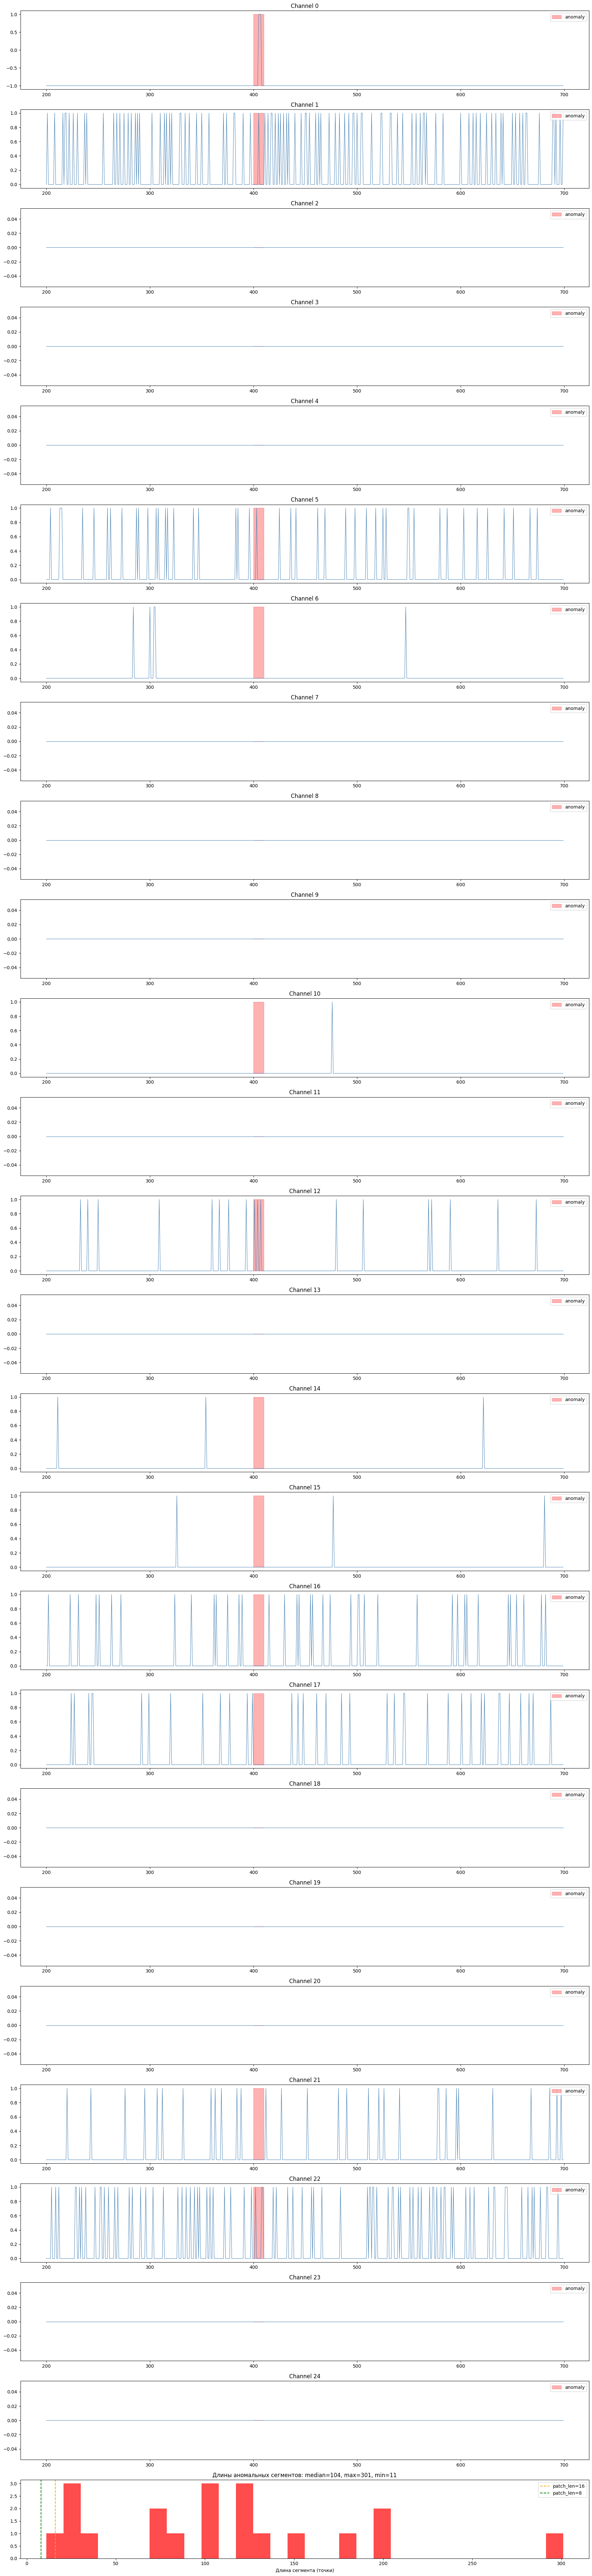


Аномальных сегментов: 20
Медиана длины: 104 точек
Среднее: 108.5 точек
Макс: 301, Мин: 11

patch_len=16 покрывает аномалию целиком? 5% сегментов
patch_len=8  покрывает аномалию целиком? 0% сегментов

=== Сила аномалий ===
Среднее |z-score| аномальных точек: 0.17
Макс    |z-score| аномальных точек: 129.71
(z-score < 2 = аномалии слабо выражены, > 5 = хорошо заметны)


In [ ]:
fig, axes = plt.subplots(N_CHANNELS + 1, 1, figsize=(18, 3 * (N_CHANNELS + 1)))

first_anom = np.where(point_labels == 1)[0][0]
start = max(0, first_anom - 200)
end   = min(len(test_norm), first_anom + 300)
t     = np.arange(start, end)

for c in range(N_CHANNELS):
    axes[c].plot(t, test_norm[start:end, c], linewidth=0.8, color='steelblue')
    axes[c].fill_between(t, test_norm[start:end, c].min(), test_norm[start:end, c].max(),
                         where=point_labels[start:end]==1,
                         alpha=0.3, color='red', label='anomaly')
    axes[c].set_title(f'Channel {c}')
    axes[c].legend(loc='upper right')

anom_lengths = []
in_anom = False
length = 0
for lab in point_labels:
    if lab == 1:
        in_anom = True
        length += 1
    elif in_anom:
        anom_lengths.append(length)
        length = 0
        in_anom = False

axes[-1].hist(anom_lengths, bins=30, color='red', alpha=0.7)
axes[-1].set_title(f'Длины аномальных сегментов: median={np.median(anom_lengths):.0f}, '
                   f'max={np.max(anom_lengths)}, min={np.min(anom_lengths)}')
axes[-1].set_xlabel('Длина сегмента (точки)')
axes[-1].axvline(16, color='orange', linestyle='--', label='patch_len=16')
axes[-1].axvline(8,  color='green',  linestyle='--', label='patch_len=8')
axes[-1].legend()

plt.tight_layout()
plt.show()

print(f"\nАномальных сегментов: {len(anom_lengths)}")
print(f"Медиана длины: {np.median(anom_lengths):.0f} точек")
print(f"Среднее: {np.mean(anom_lengths):.1f} точек")
print(f"Макс: {np.max(anom_lengths)}, Мин: {np.min(anom_lengths)}")
print(f"\npatch_len=16 покрывает аномалию целиком? "
      f"{(np.array(anom_lengths) <= 16).mean()*100:.0f}% сегментов")
print(f"patch_len=8  покрывает аномалию целиком? "
      f"{(np.array(anom_lengths) <= 8).mean()*100:.0f}% сегментов")

print(f"\n=== Сила аномалий ===")
normal_std  = test_norm[point_labels == 0].std(axis=0)
anom_vals   = test_norm[point_labels == 1]
normal_mean = test_norm[point_labels == 0].mean(axis=0)
z_scores    = np.abs((anom_vals - normal_mean) / (normal_std + 1e-8))
print(f"Среднее |z-score| аномальных точек: {z_scores.mean():.2f}")
print(f"Макс    |z-score| аномальных точек: {z_scores.max():.2f}")
print(f"(z-score < 2 = аномалии слабо выражены, > 5 = хорошо заметны)")

## 4. Эксперименты: mask_ratio × mask_type

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

results = []
mask_ratios = [0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8]
mask_type = "random"

print("=== Улучшенные эксперименты: случайное маскирование ===")
print("30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка\n")

for ratio in mask_ratios:
    print(f"\n{'='*80}")
    print(f"Обучение с mask_ratio = {ratio*100:.0f}%  (mask_type={mask_type})")
    print('='*80)

    model = build_timercd(
        n_channels=N_CHANNELS,
        seq_len=WINDOW_SIZE,
        size="medium",
        mask_type=mask_type,
        device=str(device)
    )

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

    best_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    max_patience = 8

    torch.manual_seed(42 + int(ratio*100))

    for epoch in range(30):
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1:2d}", leave=False):
            batch = batch.to(device)

            loss = model.compute_loss(batch, mask_ratio=ratio)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        metrics = evaluate(model, test_loader, test_norm, point_labels,
                           WINDOW_SIZE, STRIDE, device)

        scheduler.step(avg_loss)

        current_f1 = metrics['f1']

        print(f"Epoch {epoch+1:2d} | loss={avg_loss:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"F1={current_f1:.4f} (P={metrics['precision']:.4f}, R={metrics['recall']:.4f}) | "
              f"RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if current_f1 > best_f1 + 1e-4:
            best_f1 = current_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"   >>> Новая лучшая F1: {best_f1:.4f} <<<")
        else:
            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"   Ранняя остановка на эпохе {epoch+1} (F1 не улучшался {max_patience} эпох)")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    final_metrics = evaluate(model, test_loader, test_norm, point_labels,
                             WINDOW_SIZE, STRIDE, device)

    save_path = f"models/timercd_{mask_type}_ratio{int(ratio*100):02d}.pth"
    torch.save(model.state_dict(), save_path)

    res = {
        'mask_type': mask_type,
        'mask_ratio': ratio,
        'epoch_best': epoch + 1 - patience_counter,
        **final_metrics
    }
    results.append(res)

    print(f"Готово для ratio={ratio:.2f} → best F1={final_metrics['f1']:.4f}, ROC-AUC={final_metrics['roc_auc']:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df.to_csv("results/timercd_random_improved_results.csv", index=False)
print("Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results.csv")

=== Улучшенные эксперименты: случайное маскирование ===
30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка


Обучение с mask_ratio = 0%  (mask_type=random)


Epoch  1:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch  1 | loss=0.4560 | ROC-AUC=0.7375 | F1=0.2449 (P=0.2708, R=0.2236) | RMSE=0.1227 | MAE=0.0227 | lr=1.00e-04
   >>> Новая лучшая F1: 0.2449 <<<


Epoch  2:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch  2 | loss=0.3631 | ROC-AUC=0.7384 | F1=0.2490 (P=0.2753, R=0.2273) | RMSE=0.1223 | MAE=0.0229 | lr=1.00e-04
   >>> Новая лучшая F1: 0.2490 <<<


...

Epoch 23 | loss=0.3271 | ROC-AUC=0.7096 | F1=0.1469 (P=0.1542, R=0.1402) | RMSE=0.0958 | MAE=0.0178 | lr=1.00e-04


Epoch 24:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 24 | loss=0.3151 | ROC-AUC=0.7084 | F1=0.1470 (P=0.1625, R=0.1342) | RMSE=0.0956 | MAE=0.0178 | lr=1.00e-04


Epoch 25:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 25 | loss=0.3158 | ROC-AUC=0.7025 | F1=0.1498 (P=0.1447, R=0.1554) | RMSE=0.0954 | MAE=0.0178 | lr=1.00e-04
   Ранняя остановка на эпохе 25 (F1 не улучшался 8 эпох)
Готово для ratio=0.80 → best F1=0.2470, ROC-AUC=0.7353

Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results.csv


In [ ]:
results_df

,mask_type,mask_ratio,epoch_best,roc_auc,f1,precision,recall,threshold,rmse,mae
0,random,0.0,2,0.7384,0.2490,0.2753,0.2273,0.0519,0.1223,0.0229
1,random,0.1,2,0.7391,0.2490,0.2753,0.2273,0.0528,0.1236,0.0230
2,random,0.2,9,0.7383,0.2515,0.2781,0.2296,0.0521,0.1227,0.0229
3,random,0.3,1,0.7390,0.2525,0.2792,0.2305,0.0530,0.1234,0.0231
4,random,0.4,2,0.7387,0.2495,0.2758,0.2278,0.0526,0.1233,0.0229
5,random,0.6,2,0.7388,0.2480,0.2741,0.2264,0.0525,0.1234,0.0231
6,random,0.8,17,0.7353,0.2470,0.2897,0.2153,0.0514,0.1174,0.0222


## 5. Визуализация результатов

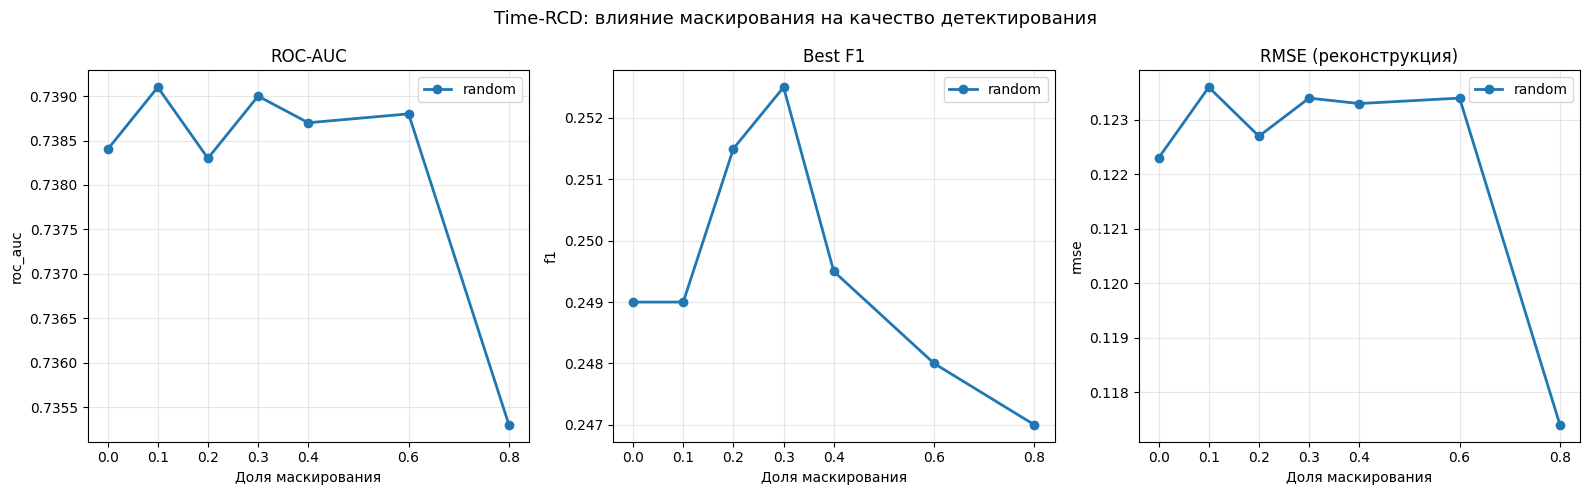

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['roc_auc', 'f1', 'rmse']
titles = ['ROC-AUC', 'Best F1', 'RMSE (реконструкция)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for mask_type, group in results_df.groupby('mask_type'):
        ax.plot(group['mask_ratio'], group[metric], 'o-', label=mask_type, linewidth=2)
    ax.set_xlabel('Доля маскирования')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(results_df['mask_ratio'].unique())

plt.suptitle('Time-RCD: влияние маскирования на качество детектирования', fontsize=13)
plt.tight_layout()
plt.show()

## Блочное маскирование

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

results = []
mask_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]
mask_type = "block"

print("=== Улучшенные эксперименты: случайное маскирование ===")
print("30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка\n")

for ratio in mask_ratios:
    print(f"\n{'='*80}")
    print(f"Обучение с mask_ratio = {ratio*100:.0f}%  (mask_type={mask_type})")
    print('='*80)

    model = build_timercd(
        n_channels=N_CHANNELS,
        seq_len=WINDOW_SIZE,
        size="medium",
        mask_type=mask_type,
        device=str(device)
    )

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)

    best_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    max_patience = 8

    torch.manual_seed(42 + int(ratio*100))

    for epoch in range(30):
        model.train()
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1:2d}", leave=False):
            batch = batch.to(device)

            loss = model.compute_loss(batch, mask_ratio=ratio)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        metrics = evaluate(model, test_loader, test_norm, point_labels,
                           WINDOW_SIZE, STRIDE, device)

        scheduler.step(avg_loss)

        current_f1 = metrics['f1']

        print(f"Epoch {epoch+1:2d} | loss={avg_loss:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"F1={current_f1:.4f} (P={metrics['precision']:.4f}, R={metrics['recall']:.4f}) | "
              f"RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if current_f1 > best_f1 + 1e-4:
            best_f1 = current_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"   >>> Новая лучшая F1: {best_f1:.4f} <<<")
        else:
            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"   Ранняя остановка на эпохе {epoch+1} (F1 не улучшался {max_patience} эпох)")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    final_metrics = evaluate(model, test_loader, test_norm, point_labels,
                             WINDOW_SIZE, STRIDE, device)

    save_path = f"models/timercd_{mask_type}_ratio{int(ratio*100):02d}.pth"
    torch.save(model.state_dict(), save_path)

    res = {
        'mask_type': mask_type,
        'mask_ratio': ratio,
        'epoch_best': epoch + 1 - patience_counter,
        **final_metrics
    }
    results.append(res)

    print(f"Готово для ratio={ratio:.2f} → best F1={final_metrics['f1']:.4f}, ROC-AUC={final_metrics['roc_auc']:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df.to_csv("results/timercd_random_improved_results_block.csv", index=False)
print("Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results_block.csv")

In [ ]:
results_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['roc_auc', 'f1', 'rmse']
titles = ['ROC-AUC', 'Best F1', 'RMSE (реконструкция)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for mask_type, group in results_df.groupby('mask_type'):
        ax.plot(group['mask_ratio'], group[metric], 'o-', label=mask_type, linewidth=2)
    ax.set_xlabel('Доля маскирования')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(results_df['mask_ratio'].unique())

plt.suptitle('Time-RCD: влияние маскирования на качество детектирования', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)

mask_ratios  = [0.0, 0.2, 0.4, 0.6, 0.8]
all_results  = []

for mask_type in ["random", "block"]:
    results = []
    print(f"\n{'='*80}")
    print(f"mask_type = {mask_type}")
    print('='*80)

    for ratio in mask_ratios:
        print(f"\n── mask_ratio = {ratio*100:.0f}% ──")
        torch.manual_seed(42 + int(ratio * 100))

        model = build_timercd(
            n_channels = N_CHANNELS,
            seq_len    = WINDOW_SIZE,
            size       = "medium",
            mask_type  = mask_type,
            device     = str(device),
        )

        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
        )

        best_val_loss    = float("inf")
        best_state       = None
        patience_counter = 0
        max_patience     = 15   

        for epoch in range(100):   

            model.train()
            train_loss = 0.0
            for batch in tqdm(train_loader, desc=f"Ep {epoch+1:3d}", leave=False):
                batch = batch.to(device)
                loss  = model.compute_loss(
                    batch,
                    mask_ratio = ratio,
                    mask_type  = mask_type, 
                )
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for vb in test_loader:
                    vb        = vb.to(device)
                    val_loss += model.compute_loss(
                        vb, mask_ratio=ratio, mask_type=mask_type
                    ).item()
            val_loss /= len(test_loader)
            scheduler.step(val_loss)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                metrics = evaluate(model, test_loader, test_norm,
                                   point_labels, WINDOW_SIZE, STRIDE, device)
                print(f"  Ep {epoch+1:3d} | "
                      f"train={train_loss:.4f} val={val_loss:.4f} | "
                      f"ROC-AUC={metrics['roc_auc']:.4f} "
                      f"F1={metrics['f1']:.4f} "
                      f"(P={metrics['precision']:.3f} R={metrics['recall']:.3f}) | "
                      f"RMSE={metrics['rmse']:.4f} | "
                      f"lr={optimizer.param_groups[0]['lr']:.1e}")

            if val_loss < best_val_loss - 1e-4:
                best_val_loss    = val_loss
                best_state       = copy.deepcopy(model.state_dict())
                patience_counter = 0
                print(f"    >>> best val_loss={best_val_loss:.4f} (ep {epoch+1}) <<<")
            else:
                patience_counter += 1

            if patience_counter >= max_patience:
                print(f"  Early stop @ epoch {epoch+1}")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        final = evaluate(model, test_loader, test_norm,
                         point_labels, WINDOW_SIZE, STRIDE, device)
        torch.save(model.state_dict(),
                   f"models/msl_{mask_type}_ratio{int(ratio*100):02d}.pth")

        res = dict(mask_type=mask_type, mask_ratio=ratio,
                   epoch_best=epoch + 1 - patience_counter, **final)
        results.append(res)
        all_results.append(res)
        print(f"  Итог: ROC-AUC={final['roc_auc']:.4f} "
              f"F1={final['f1']:.4f} RMSE={final['rmse']:.4f}")

    df = pd.DataFrame(results).round(4)
    df.to_csv(f"results/msl_{mask_type}_results.csv", index=False)
    print(f"\n{df.to_string(index=False)}")

all_df = pd.DataFrame(all_results).round(4)
all_df.to_csv("results/msl_all_results.csv", index=False)
print("\n", all_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(
    axes, ["roc_auc", "f1", "rmse"], ["ROC-AUC", "F1", "RMSE"]
):
    for mt, grp in all_df.groupby("mask_type"):
        ax.plot(grp["mask_ratio"] * 100, grp[metric], "o-",
                label=mt, linewidth=2, markersize=7)
    ax.set_xlabel("Доля маскирования, %")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0, 20, 40, 60, 80])

plt.suptitle("MSL: влияние маскирования на качество", fontsize=13)
plt.tight_layout()
plt.savefig("results/msl_masking_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)

RATIOS_BY_TYPE = {
    "channel_wise": [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 0.995],
    "hybrid":     [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 0.995],
}

all_results = []

for mask_type in ["channel_wise", "hybrid"]:
    results     = []
    mask_ratios = RATIOS_BY_TYPE[mask_type]

    print(f"\n{'='*80}")
    print(f"mask_type = {mask_type}  |  ratios = {mask_ratios}")
    if mask_type == "channel_wise":
        print(f"(N_CHANNELS={N_CHANNELS}: "
              f"ratio=0.2 → {int(0.2*N_CHANNELS)} ch masked, "
              f"ratio=0.6 → {int(0.6*N_CHANNELS)} ch masked, "
              f"ratio=0.9 → {int(0.9*N_CHANNELS)} ch masked)")
    print('='*80)

    for ratio in mask_ratios:
        print(f"\n── mask_ratio = {ratio*100:.0f}% ──")
        torch.manual_seed(42 + int(ratio * 100))

        model = build_timercd(
            n_channels = N_CHANNELS,
            seq_len    = WINDOW_SIZE,
            size       = "medium",
            mask_type  = mask_type,
            device     = str(device),
        )

        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
        )

        best_val_loss    = float("inf")
        best_state       = None
        patience_counter = 0
        max_patience     = 15

        for epoch in range(100):

            model.train()
            train_loss = 0.0
            for batch in tqdm(train_loader, desc=f"Ep {epoch+1:3d}", leave=False):
                batch = batch.to(device)
                loss  = model.compute_loss(
                    batch,
                    mask_ratio = ratio,
                    mask_type  = mask_type,
                )
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for vb in test_loader:
                    vb        = vb.to(device)
                    val_loss += model.compute_loss(
                        vb, mask_ratio=ratio, mask_type=mask_type
                    ).item()
            val_loss /= len(test_loader)
            scheduler.step(val_loss)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                metrics = evaluate(model, test_loader, test_norm,
                                   point_labels, WINDOW_SIZE, STRIDE, device)
                print(f"  Ep {epoch+1:3d} | "
                      f"train={train_loss:.4f} val={val_loss:.4f} | "
                      f"ROC-AUC={metrics['roc_auc']:.4f} "
                      f"F1={metrics['f1']:.4f} "
                      f"(P={metrics['precision']:.3f} R={metrics['recall']:.3f}) | "
                      f"RMSE={metrics['rmse']:.4f} | "
                      f"lr={optimizer.param_groups[0]['lr']:.1e}")

            if val_loss < best_val_loss - 1e-4:
                best_val_loss    = val_loss
                best_state       = copy.deepcopy(model.state_dict())
                patience_counter = 0
                print(f"    >>> best val_loss={best_val_loss:.4f} (ep {epoch+1}) <<<")
            else:
                patience_counter += 1

            if patience_counter >= max_patience:
                print(f"  Early stop @ epoch {epoch+1}")
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        final = evaluate(model, test_loader, test_norm,
                         point_labels, WINDOW_SIZE, STRIDE, device)
        torch.save(model.state_dict(),
                   f"models/msl_{mask_type}_ratio{int(ratio*100):03d}.pth")

        res = dict(mask_type=mask_type, mask_ratio=ratio,
                   epoch_best=epoch + 1 - patience_counter, **final)
        results.append(res)
        all_results.append(res)
        print(f"  Итог: ROC-AUC={final['roc_auc']:.4f} "
              f"F1={final['f1']:.4f} RMSE={final['rmse']:.4f}")

    df = pd.DataFrame(results).round(4)
    df.to_csv(f"results/msl_{mask_type}_results.csv", index=False)
    print(f"\n{df.to_string(index=False)}")

all_df = pd.DataFrame(all_results).round(4)
all_df.to_csv("results/msl_new_masking_results.csv", index=False)
print("\n", all_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(
    axes, ["roc_auc", "f1", "rmse"], ["ROC-AUC", "F1", "RMSE"]
):
    for mt, grp in all_df.groupby("mask_type"):
        xticks = (grp["mask_ratio"] * 100).astype(int).tolist()
        ax.plot(grp["mask_ratio"] * 100, grp[metric], "o-",
                label=mt, linewidth=2, markersize=7)
    ax.set_xlabel("Доля маскирования, %")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("MSL: channel_wise и hybrid маскирование", fontsize=13)
plt.tight_layout()
plt.savefig("results/msl_new_masking_results.png", dpi=150, bbox_inches="tight")
plt.show()